# BrandSuit AI — YouTube category + brand match

O MVP **não** é “unsafe sim/não”. Com trending, o YouTube já filtrou violência.
A pergunta é: **dado título + descrição, qual é a categoria?** Depois a marca aplica a lista dela (Nike / banco / cereal).

Trilha:

**Parte 1 (agora)**
1. Carregar o CSV + o JSON de categorias
2. Inspecionar colunas, grain, `video_id` repetido
3. Features vs label; classificação
4. Uma linha por vídeo (`TODO`)
5. Mapear `category_id` → 5 classes do MVP (`TODO`)
6. Ver a distribuição (o gráfico tem um propósito)
7. Baseline bobinho (sempre a classe mais comum)

**Parte 2 (depois)**
- ainda não (treino/teste, modelo, macro-F1)

> Rode na ordem. Kernel: **Python 3.13**. `TODO (STUDENT)` é sua vez. Mini-checks: responda com suas palavras.


## 1) Carregar os dados

Cada linha do CSV é **um vídeo em um dia de trending** (não ainda “um vídeo único”).

Pergunta para guardar na cabeça:

> Olhando só título + descrição, consigo adivinhar a categoria que o YouTube deu?

`category_id` é o **gabarito** (`y`). Não entra em `X` — isso seria cola.


In [45]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# KEEP: notebooks/ está um nível abaixo da pasta do projeto
RAW = Path("../data/raw")
csv_path = RAW / "USvideos.csv"
json_path = RAW / "US_category_id.json"
print("csv:", csv_path.resolve())
print("exists:", csv_path.exists())

df = pd.read_csv(csv_path)
df.head(3)

csv: C:\Users\natha\OneDrive\Documentos\data science\Python Projects\bar-ilan-classes\Brandsafe-ai\data\raw\USvideos.csv
exists: True


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...


## 2) Inspecionar

Compare `shape[0]` (linhas) com `video_id.nunique()` (vídeos de verdade).


In [46]:
print("shape:", df.shape)
print("\ncolumns:", list(df.columns))
print("\ndtypes:\n", df.dtypes)
print("\nlinhas:", len(df))
print("video_id únicos:", df["video_id"].nunique())
print("\ndescription nulos:", df["description"].isna().sum())

# KEEP: size() = COUNT(*) por category_id; False (F maiúsculo) não é false
category_id_qty = (
    df.groupby("category_id").size().reset_index(name="qty")
)
print("\n qty by category id:")
print(category_id_qty.sort_values("qty", ascending=False))

shape: (40949, 16)

columns: ['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description']

dtypes:
 video_id                    str
trending_date               str
title                       str
channel_title               str
category_id               int64
publish_time                str
tags                        str
views                     int64
likes                     int64
dislikes                  int64
comment_count             int64
thumbnail_link              str
comments_disabled          bool
ratings_disabled           bool
video_error_or_removed     bool
description                 str
dtype: object

linhas: 40949
video_id únicos: 6351

description nulos: 570

 qty by category id:
    category_id   qty
9            24  9964
2            10  6472
11           26  4146
8            23  3457


O JSON traduz o número `category_id` para um nome (Sports, Music, …).

**Termo:** `category_id`  
**Neste projeto:** é o `y` cru. Depois mapeamos para 5 classes.  
**Na entrevista:** “Usei a categoria oficial como label. Não coloquei ela nas features.”


In [47]:
# KEEP: o JSON da API do YouTube vem aninhado: items → snippet → title
with json_path.open(encoding="utf-8") as f:
    payload = json.load(f)

id_to_name = {}
for item in payload["items"]:
    cat_id = int(item["id"])
    name = item["snippet"]["title"]
    id_to_name[cat_id] = name

print("quantas categorias no JSON:", len(id_to_name))
for cat_id, name in sorted(id_to_name.items()):
    print(f"{cat_id:3d}  {name}")

quantas categorias no JSON: 32
  1  Film & Animation
  2  Autos & Vehicles
 10  Music
 15  Pets & Animals
 17  Sports
 18  Short Movies
 19  Travel & Events
 20  Gaming
 21  Videoblogging
 22  People & Blogs
 23  Comedy
 24  Entertainment
 25  News & Politics
 26  Howto & Style
 27  Education
 28  Science & Technology
 29  Nonprofits & Activism
 30  Movies
 31  Anime/Animation
 32  Action/Adventure
 33  Classics
 34  Comedy
 35  Documentary
 36  Drama
 37  Family
 38  Foreign
 39  Horror
 40  Sci-Fi/Fantasy
 41  Thriller
 42  Shorts
 43  Shows
 44  Trailers


### Mini-check (escreva com suas palavras)

- **Features (`X`)** = ...
- **Target / label (`y`)** = ...
- Este problema é **regressão** ou **classificação**? Por quê?
- Por que `category_id` **não** pode ir para `X`?
- Por que há mais **linhas** do que **vídeos únicos**?


## 3) Sua vez: uma linha por vídeo

O grain do modelo é **um vídeo**, não um dia no ranking.
Se o mesmo `video_id` ficar no treino e no teste, o teste cola.

A categoria das cópias é a mesma. Você **não** reclassifica. Você **descarta cópias**.


In [48]:
# TODO (STUDENT): deixe um registro por video_id
# HINT: DataFrame.drop_duplicates(subset=..., keep="first")
# A linha abaixo AINDA está errada de propósito (copia tudo). Troque.
df_one = df.drop_duplicates(subset="video_id")

print("linhas originais :", len(df))
print("depois do seu drop:", len(df_one))
print("video_id únicos  :", df_one["video_id"].nunique())
# Se o drop estiver certo, as duas últimas linhas batem (~6351).

linhas originais : 40949
depois do seu drop: 6351
video_id únicos  : 6351


## 4) Sua vez: 5 classes do MVP

Decisão (D2): Sports, News/Politics, Gaming, Entertainment, Other.

| YouTube (nome no JSON) | Nosso `y` |
|---|---|
| Sports | Sports |
| News & Politics | News / Politics |
| Gaming | Gaming |
| Entertainment, Comedy, Music, Film & Animation | Entertainment |
| o resto | Other |

Complete o dicionário. Os três primeiros já estão; falta Entertainment.


In [49]:
# TODO (STUDENT): complete Entertainment (ids que você viu no print do JSON)
# HINT: procure Music, Comedy, Film & Animation, Entertainment na lista
category_mapping = {
    "Autos & Vehicles": "Lifestyle & Interests",
    "Comedy": "Entertainment & Culture",
    "Education": "Education, Science & Technology",
    "Entertainment": "Entertainment & Culture",
    "Film & Animation": "Entertainment & Culture",
    "Gaming": "Gaming",
    "Howto & Style": "Lifestyle & Interests",
    "Music": "Entertainment & Culture",
    "News & Politics": "News, Politics & Society",
    "Nonprofits & Activism": "News, Politics & Society",
    "People & Blogs": "Lifestyle & Interests",
    "Pets & Animals": "Lifestyle & Interests",
    "Science & Technology": "Education, Science & Technology",
    "Shows": "Entertainment & Culture",
    "Sports": "Sports",
    "Travel & Events": "Lifestyle & Interests"
}



df_one = df_one.copy()
# KEEP: o nome vem do JSON; o y vem do seu de-para. Tudo em df_one (vídeos únicos).
df_one["youtube_name"] = df_one["category_id"].map(id_to_name)
df_one["y"] = df_one["youtube_name"].map(category_mapping).fillna("Other")

df_grouped_category = df_one["y"].value_counts().reset_index(name="qty")
df_perc = df_grouped_category.assign(
    perc=round(df_grouped_category["qty"] / len(df_one), 2)
)

print(df_perc.sort_values("perc", ascending=False))
print("\nconferência (youtube_name vs y):")
print(pd.crosstab(df_one["youtube_name"], df_one["y"]))
print()

                                 y   qty  perc
0          Entertainment & Culture  3287  0.52
1            Lifestyle & Interests  1361  0.21
2  Education, Science & Technology   630  0.10
3         News, Politics & Society   519  0.08
4                           Sports   451  0.07
5                           Gaming   103  0.02

conferência (youtube_name vs y):
y                      Education, Science & Technology  \
youtube_name                                             
Autos & Vehicles                                     0   
Comedy                                               0   
Education                                          250   
Entertainment                                        0   
Film & Animation                                     0   
Gaming                                               0   
Howto & Style                                        0   
Music                                                0   
News & Politics                                      0   

## 5) Visualizar a pergunta

Pergunta do gráfico: **as 5 classes estão equilibradas, ou uma delas é enorme?**
Isso diz se o chute “sempre a classe grande” já acerta muito.


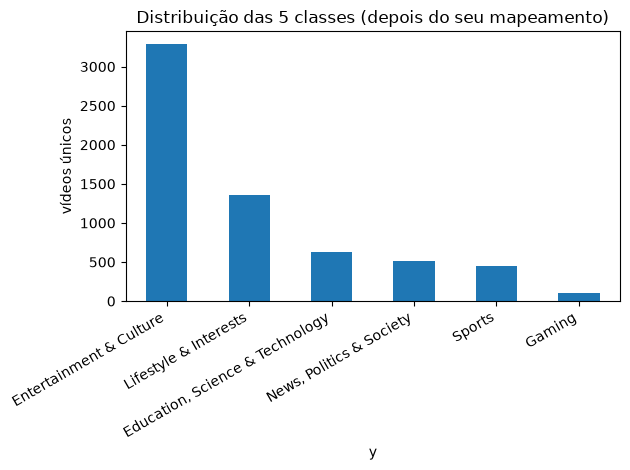

y
Entertainment & Culture            3287
Lifestyle & Interests              1361
Education, Science & Technology     630
News, Politics & Society            519
Sports                              451
Gaming                              103
Name: count, dtype: int64


In [50]:
counts = df_one["y"].value_counts()
ax = counts.plot(kind="bar")
ax.set_ylabel("vídeos únicos")
ax.set_title("Distribuição das 5 classes (depois do seu mapeamento)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print(counts)

Olhe o gráfico e responda:

1. Qual classe tem mais vídeos?
2. Se o bobinho **sempre** chutar essa classe, a accuracy fica alta ou baixa? Por quê?
3. Music ainda está em Other? (se sim, o mapeamento de Entertainment não acabou)


## 6) Baseline bobinho

Ainda **não** é um modelo. É o chão: sempre a classe mais comum.
O modelo da Parte 2 precisa **ganhar** deste número — senão não aprendeu nada útil.


In [51]:
# Baseline = chute bobinho: sempre a classe mais comum
most_common = df_one["y"].mode()[0]
baseline_acc = (df_one["y"] == most_common).mean()
print("classe mais comum:", most_common)
print("accuracy do baseline:", round(baseline_acc, 3))
print("n vídeos:", len(df_one))

classe mais comum: Entertainment & Culture
accuracy do baseline: 0.518
n vídeos: 6351


## 7) Opcional: montar `X` e `y` (sem treinar)

Description às vezes vem vazia. Juntamos título + descrição numa string.


In [52]:
# KEEP: fillna porque NaN + string vira NaN de novo
df_one["text"] = (
    df_one["title"].fillna("") + " " + df_one["description"].fillna("")
).str.strip()

X = df_one["text"]
y = df_one["y"]
print("X len:", len(X), "y len:", len(y))
print("exemplo X:\n", X.iloc[0][:300])

X len: 6351 y len: 6351
exemplo X:
 WE WANT TO TALK ABOUT OUR MARRIAGE SHANTELL'S CHANNEL - https://www.youtube.com/shantellmartin\nCANDICE - https://www.lovebilly.com\n\nfilmed this video in 4k on this -- http://amzn.to/2sTDnRZ\nwith this lens -- http://amzn.to/2rUJOmD\nbig drone - http://tinyurl.com/h4ft3oy\nOTHER GEAR ---  http://a


### Checkpoint

Manda no chat, com suas palavras:

1. Quantas linhas depois do `drop`? Bate com os `video_id` únicos?
2. Music/Comedy foram para Entertainment ou ficaram em Other?
3. Qual foi a accuracy do baseline e por que **não** basta para o cereal infantil?

Não avance a Parte 2 ainda.


## 8) Parte 2 — treino, prova e o bobinho no *test*

Rode as células da Parte 1 antes (`df_one` com coluna `y`).

**Historinha**
- `train` = cartas de estudo (o modelo pode ver o gabarito)
- `test` = prova escondida (só vemos a nota no fim)
- `stratify=y` = a prova tem a **mesma mistura** de classes que o caderno (senão a prova pode ficar só Entertainment)

O baseline de 0.52 foi no dataset **inteiro**. Na Parte 2 comparamos com o bobinho **só no test** — senão é cola.


### Mapa da Parte 2 (não é treino vs precision)

Precision e recall nascem **juntos**, só no test. O que muda é a pilha.

```text
6351 vídeos (df_one)
├── 80% TRAIN  →  caderno (pode ver gabarito)
│     ├── TfidfVectorizer.fit_transform(X_train)   →  palavras do caderno
│     └── LogisticRegression.fit(..., y_train)    →  o aluno estuda
│
└── 20% TEST   →  prova (gabarito escondido até o fim)
      ├── vec.transform(X_test)                   →  mesmas colunas, sem cola
      ├── model.predict(...) → y_pred            →  chute do aluno
      └── compara y_pred com y_test
            ├── accuracy     →  acertos / todos os 1271
            ├── recall News  →  acertos News / 104 que ERAM News
            └── precision News →  acertos News / ~83 que ELE DISSE News
```

```mermaid
flowchart TD
  A["df_one ~6351 vídeos"] --> B[train_test_split]
  B --> TR["TRAIN 80%\nX_train + y_train"]
  B --> TE["TEST 20%\nX_test + y_test"]
  TR --> V["TF-IDF fit_transform"]
  V --> F["model.fit estudar"]
  TE --> T["TF-IDF transform"]
  F --> P["model.predict"]
  T --> P
  P --> YP["y_pred chutes"]
  TE --> YT["y_test gabarito"]
  YP --> C[compara na PROVA]
  YT --> C
  C --> ACC["accuracy\ntodos os vídeos"]
  C --> REC["recall News\ndenominador = eram News"]
  C --> PRE["precision News\ndenominador = disse News"]
```


In [53]:
# KEEP: fillna porque NaN + texto vira NaN
text = (df_one["title"].fillna("") + " " + df_one["description"].fillna("")).str.strip()
X = text
y = df_one["y"]

from sklearn.model_selection import train_test_split

# 80% estudar, 20% prova. random_state=42 = a mesma prova se você rodar de novo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("train:", X_train.shape, "test:", X_test.shape)
print("treino (proporção):")
print(y_train.value_counts(normalize=True).round(3))
print("prova (proporção):")
print(y_test.value_counts(normalize=True).round(3))

# Bobinho honesto: chuta a classe mais comum do TREINO, nota na PROVA
most_common = y_train.mode()[0]
baseline_acc_test = (y_test == most_common).mean()
print("\nbobinho (sempre", most_common, ") no test:", round(baseline_acc_test, 3))


train: (5080,) test: (1271,)
treino (proporção):
y
Entertainment & Culture            0.518
Lifestyle & Interests              0.214
Education, Science & Technology    0.099
News, Politics & Society           0.082
Sports                             0.071
Gaming                             0.016
Name: proportion, dtype: float64
prova (proporção):
y
Entertainment & Culture            0.518
Lifestyle & Interests              0.214
Education, Science & Technology    0.099
News, Politics & Society           0.082
Sports                             0.071
Gaming                             0.017
Name: proportion, dtype: float64

bobinho (sempre Entertainment & Culture ) no test: 0.518


## 9) Texto → números, depois o aluno

O Logistic Regression não lê frase. Primeiro viramos o texto numa **tabela de números**.

**Termo:** *TF-IDF*  
**Neste projeto:** cada palavra (ou par de palavras) vira uma coluna; o número é “isso aparece neste vídeo e não em todos”.  
**Na entrevista:** “É um jeito clássico de vetorizar texto antes de um modelo linear. `fit` do vetor só no treino para não vazar o vocabulário da prova.”

Depois:

| Código | Historinha |
|---|---|
| `.fit(X_train, y_train)` | o aluno estuda |
| `.predict(X_test)` | a prova, sem gabarito |
| `y_pred` | as respostas do aluno |
| `y_test` | o gabarito |
| `accuracy_score` | % de acerto |


In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# KEEP: fit do TF-IDF só no treino. transform no test usa o mesmo vocabulário.
vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 1), min_df=2)
X_train_vec = vec.fit_transform(X_train)  # aprende quais palavras existem no caderno
X_test_vec = vec.transform(X_test)        # prova: não cria coluna nova com gabarito

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)           # estudar
y_pred = model.predict(X_test_vec)        # prova

model_acc = accuracy_score(y_test, y_pred)
model_f1 = f1_score(y_test, y_pred, average="macro")

print("accuracy do modelo :", round(model_acc, 3))
print("accuracy do bobinho:", round(baseline_acc_test, 3))
print("macro-F1 do modelo :", round(model_f1, 3))


accuracy do modelo : 0.796
accuracy do bobinho: 0.518
macro-F1 do modelo : 0.673


## 10) Onde erra (confusion matrix)

Accuracy é um número. A matriz mostra **qual classe foi confundida com qual**.

Para o cereal: a célula perigosa é gabarito **News, Politics & Society** previsto como **Entertainment & Culture** (a policy diria SIM).

**Termo:** *macro-F1*  
**Neste projeto:** F1 de cada classe, depois a média igual. Entertainment não esconde News.  
**Na entrevista:** “Não otimizei só accuracy. Com classe grande, eu olho macro-F1 e a linha de News.”


                                 precision    recall  f1-score   support

Education, Science & Technology       0.84      0.52      0.64       126
        Entertainment & Culture       0.77      0.94      0.85       658
                         Gaming       1.00      0.14      0.25        21
          Lifestyle & Interests       0.79      0.71      0.75       272
       News, Politics & Society       0.89      0.71      0.79       104
                         Sports       0.95      0.63      0.76        90

                       accuracy                           0.80      1271
                      macro avg       0.87      0.61      0.67      1271
                   weighted avg       0.81      0.80      0.79      1271



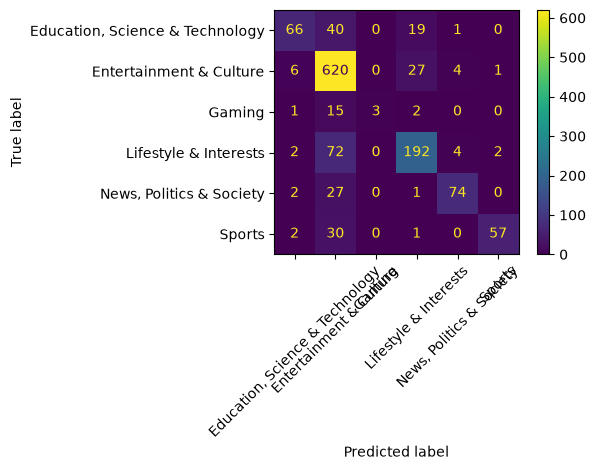

In [55]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)
plt.tight_layout()
plt.show()


Olhe o relatório e a matriz:

1. A accuracy do modelo ficou **maior**, **menor** ou **igual** à do bobinho no test?
2. Qual classe tem recall mais baixo?
3. O cereal se machuca se News for previsto como Entertainment. Essa célula está **escura** (muitos erros) ou **clara**?

### TODO (STUDENT)

Na célula abaixo, rode de novo o mesmo modelo com `class_weight="balanced"` (o aluno presta mais atenção nas classes raras). Compare macro-F1 e o recall de News.
Não apague o modelo da célula 9; copie e mude **só** essa opção.


In [56]:
# TODO (STUDENT): mesmo TF-IDF, mesmo split, LogisticRegression com class_weight="balanced"
# HINT: class_weight="balanced" entra no LogisticRegression(...)
# A linha abaixo AINDA é o modelo sem peso. Troque.

model_b = LogisticRegression(max_iter=1000, class_weight = 'balanced')  # falta o peso
model_b.fit(X_train_vec, y_train)
y_pred_b = model_b.predict(X_test_vec)

print("macro-F1 sem peso :", round(f1_score(y_test, y_pred, average="macro"), 3))
print("macro-F1 com peso?:", round(f1_score(y_test, y_pred_b, average="macro"), 3))
print("\nrelatório (sua versão):")
print(classification_report(y_test, y_pred_b, zero_division=0))


macro-F1 sem peso : 0.673
macro-F1 com peso?: 0.718

relatório (sua versão):
                                 precision    recall  f1-score   support

Education, Science & Technology       0.68      0.71      0.70       126
        Entertainment & Culture       0.89      0.81      0.85       658
                         Gaming       0.43      0.48      0.45        21
          Lifestyle & Interests       0.69      0.77      0.73       272
       News, Politics & Society       0.68      0.89      0.77       104
                         Sports       0.87      0.76      0.81        90

                       accuracy                           0.79      1271
                      macro avg       0.71      0.74      0.72      1271
                   weighted avg       0.80      0.79      0.79      1271



### Checkpoint — Parte 2

Manda no chat:

1. Accuracy do modelo vs bobinho no **test** (dois números).
2. `class_weight="balanced"` ajudou o recall de News? Sim/não + um número.
3. Em uma frase de entrevista: por que `fit` do TF-IDF não pode usar o `X_test`?

Não avance para demo/Streamlit ainda.


## 11) Error analysis — o false yes do cereal

Rode antes a célula do modelo **com** `class_weight="balanced"` (`y_pred_b`).

Não olhamos accuracy de novo. Olhamos **vídeos reais** em que:

- gabarito = News, Politics & Society
- chute = Entertainment & Culture

A policy do cereal **aceita** Entertainment, então esses erros viram **SIM** no jornal.

Hipótese (você confirma olhando os títulos): o texto mistura celebridade/comédia **e** política, ou o YouTube rotulou News em algo que parece talk show.


In [ ]:
# KEEP: y_test e Series; y_pred_b e array. Alinhamos pelo valor, nao JOIN.
NEWS = "News, Politics & Society"
ENT = "Entertainment & Culture"

err = pd.DataFrame({
    "title": df_one.loc[X_test.index, "title"].values,
    "text": X_test.to_numpy(),
    "y_true": y_test.to_numpy(),
    "y_pred": y_pred_b,
})

news_row = err[err["y_true"] == NEWS]
print("News na prova:", len(news_row))
print("chutes quando era News:")
print(news_row["y_pred"].value_counts())

cereal_false_yes = err[(err["y_true"] == NEWS) & (err["y_pred"] == ENT)]
print("\nfalse yes do cereal (News -> Entertainment):", len(cereal_false_yes))
cereal_false_yes[["title", "y_true", "y_pred"]].head(15)


Olhe os títulos da tabelinha e responda:

1. Quantos News da prova foram para Entertainment? (o print acima)
2. Algum título **parece** jornal de verdade (eleição, senado, Trump)?
3. Algum parece mais Late Night / comediante falando de política? (aí o erro pode ser o **label** do YouTube, não só o modelo)

### TODO (STUDENT)

Na célula abaixo, copie **dois** títulos: um que você acha erro do modelo, um que você acha label duvidoso.


In [ ]:
# TODO (STUDENT): troque os ... pelas suas palavras
print("Exemplo A (erro do modelo): ...")
print("  porque o texto fala de ... e mesmo assim o chute foi Entertainment")
print()
print("Exemplo B (label duvidoso): ...")
print("  porque ...")


### Checkpoint — error analysis

Manda no chat:

1. Quantos false yes (News → Entertainment) na prova?
2. Sua hipótese em uma frase: o modelo erra mais por **palavras de show** ou por **label ruim**?
3. Qual seria o próximo experimento (sem rede neural): mais n-grams, mais peso em News, ou relabel à mão de 20 vídeos?

Não monte Streamlit ainda.


## 12) Experimento — n-grams `(1, 2)`

Você escolheu isso porque a hipótese foi **palavras de show**: o modelo vê `star` / `Coach` e não vê a frase de jornal.

- `(1, 1)` = só palavra solta (`submarine`, `star`)
- `(1, 2)` = palavra **e** par (`missing Argentine`, `dead at`)

Mesmo split, mesmo `y`, mesmo `class_weight="balanced"`.
**Novo** `TfidfVectorizer`: `fit` só no `X_train` (a regra do exame não mudou).

A métrica do produto neste teste: os **4** false yes (News → Entertainment). Se isso não cair, n-grams não resolveu o cereal.


In [60]:
# TODO (STUDENT): ngram_range=(1, 2). Resto igual: fit so no treino, balanced.
# HINT: (1, 1) = palavra; (1, 2) = palavra + par
# A linha abaixo AINDA e unigram. Troque.

vec_ng = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)  # falta o par
X_train_ng = vec_ng.fit_transform(X_train)
X_test_ng = vec_ng.transform(X_test)

model_ng = LogisticRegression(max_iter=1000, class_weight="balanced")
model_ng.fit(X_train_ng, y_train)
y_pred_ng = model_ng.predict(X_test_ng)

print("macro-F1 unigram :", round(f1_score(y_test, y_pred_b, average="macro"), 3))
print("macro-F1 n-grams?:", round(f1_score(y_test, y_pred_ng, average="macro"), 3))
print("\nrelatorio n-grams:")
print(classification_report(y_test, y_pred_ng, zero_division=0))

NEWS = "News, Politics & Society"
ENT = "Entertainment & Culture"
n_false_uni = ((y_test.to_numpy() == NEWS) & (y_pred_b == ENT)).sum()
n_false_ng = ((y_test.to_numpy() == NEWS) & (y_pred_ng == ENT)).sum()
print("\nfalse yes cereal (News -> Entertainment)")
print("  unigram :", n_false_uni)
print("  n-grams :", n_false_ng)


macro-F1 unigram : 0.718
macro-F1 n-grams?: 0.716

relatorio n-grams:
                                 precision    recall  f1-score   support

Education, Science & Technology       0.62      0.71      0.66       126
        Entertainment & Culture       0.91      0.79      0.85       658
                         Gaming       0.45      0.62      0.52        21
          Lifestyle & Interests       0.68      0.76      0.72       272
       News, Politics & Society       0.65      0.89      0.75       104
                         Sports       0.87      0.73      0.80        90

                       accuracy                           0.78      1271
                      macro avg       0.70      0.75      0.72      1271
                   weighted avg       0.80      0.78      0.79      1271


false yes cereal (News -> Entertainment)
  unigram : 4
  n-grams : 2


### Checkpoint — n-grams

Manda no chat:

1. Você trocou para `(1, 2)`? (se os dois macro-F1 saírem iguais, ainda está `(1, 1)`)
2. Macro-F1: unigram vs n-grams (dois números).
3. False yes do cereal: 4 → ?
4. Em uma frase: n-grams resolveu o cereal ou não?

Ainda sem Streamlit.


## 13) Os 2 que ainda quebram o jornal

n-grams cortou 4 → 2. Macro-F1 ficou igual. Para o cereal, **2 ainda é falha**.

Antes de outro `.fit`, olhe **quem** são esses 2. A pergunta muda:

- se ainda for o **submarino** → o modelo não aprendeu jornal
- se for **Jerry / Rose / Pepsi** → n-grams já pegou o que dava; o resto é label ou policy


In [ ]:
# KEEP: mesma prova, agora com y_pred_ng
NEWS = "News, Politics & Society"
ENT = "Entertainment & Culture"

still = pd.DataFrame({
    "title": df_one.loc[X_test.index, "title"].values,
    "y_true": y_test.to_numpy(),
    "y_pred": y_pred_ng,
})
still = still[(still["y_true"] == NEWS) & (still["y_pred"] == ENT)]
print("ainda false yes:", len(still))
still[["title", "y_true", "y_pred"]]


### Mini-check

1. Quais são os 2 títulos?
2. Algum deles é jornal “de verdade”?
3. Sem treinar de novo: o cereal deveria **bloquear na dúvida** (só SIM se o modelo estiver bem certo que é Sports/Entertainment)?

Manda os 2 títulos no chat.


## 14) Policy — só SIM se Sports/Entertainment estiver alto

Você escolheu não publicar no chute. `predict` só devolve o **campeão**.  
`predict_proba` devolve **6 notas** (somam 1): o quão certo o aluno está de cada classe.

Cereal allow-list = Sports + Entertainment & Culture.

`p_allow = P(Sports) + P(Entertainment)`

- se `p_allow` for baixo → **NÃO** (mesmo se o campeão for Entertainment)
- isso não é um modelo novo. É regra de produto em cima do mesmo `model_ng`.

Primeiro olhe as notas do Milo e da Rose. Depois escolha o corte.


In [62]:
# KEEP: predict = campeao; predict_proba = 6 notas
NEWS = "News, Politics & Society"
ENT = "Entertainment & Culture"
SPORTS = "Sports"

proba = model_ng.predict_proba(X_test_ng)
p_df = pd.DataFrame(proba, columns=model_ng.classes_)
p_allow = p_df[SPORTS] + p_df[ENT]

view = pd.DataFrame({
    "title": df_one.loc[X_test.index, "title"].values,
    "y_true": y_test.to_numpy(),
    "y_pred": y_pred_ng,
    "p_news": p_df[NEWS].to_numpy(),
    "p_ent": p_df[ENT].to_numpy(),
    "p_sports": p_df[SPORTS].to_numpy(),
    "p_allow": p_allow.to_numpy(),
})

leaks = (view["y_true"] == NEWS) & (view["y_pred"] == ENT)
print("notas dos 2 que o argmax chamou Entertainment:")
view.loc[leaks, ["title", "p_news", "p_ent", "p_sports", "p_allow"]]


notas dos 2 que o argmax chamou Entertainment:


,title,p_news,p_ent,p_sports,p_allow
140,Milo Takes Calls From Infowars Listeners,0.047393,0.265598,0.139285,0.404884
869,Rose McGowan Shares Her Thoughts On 'Time's Up...,0.304367,0.389266,0.081003,0.470269


Olhe `p_allow` do Milo. Esse número é a soma Sports+Entertainment.

### TODO (STUDENT)

Na célula abaixo, troque `THRESH`. Se o Milo tiver `p_allow` 0.55, um corte 0.50 **ainda publica**.


In [68]:
# TODO (STUDENT): escolha um corte. 0.50 AINDA e o padrao frouxo.
THRESH = 0.5  # troque

cereal_yes = p_allow.to_numpy() >= THRESH

n_false_yes = ((view["y_true"] == NEWS) & cereal_yes).sum()
n_lost_ent = ((view["y_true"] == ENT) & ~cereal_yes).sum()
n_yes = cereal_yes.sum()

print("THRESH:", THRESH)
print("false yes (era News, cereal publica):", n_false_yes)
print("Entertainment perdido (era Ent, cereal bloqueia):", n_lost_ent)
print("anuncios SIM na prova:", n_yes, "de", len(view))


THRESH: 0.5
false yes (era News, cereal publica): 0
Entertainment perdido (era Ent, cereal bloqueia): 201
anuncios SIM na prova: 546 de 1271


### Checkpoint — threshold

Manda no chat:

1. `p_allow` do Milo (um número).
2. Qual `THRESH` você testou?
3. False yes (News publicado) e Entertainment perdido (dois números).
4. Em uma frase: o jornal do cereal ficou seguro o bastante, ou o corte comeu demais inventário?

Ainda sem Streamlit.


## 16) Retrain — uma mudança só

Dois tipos de erro Sports → Entertainment:

- **Label:** Mulan, ópera, Halladay crash. O YouTube chamou de Sports. Treinar de novo **no mesmo y** ensina o modelo a repetir o erro.
- **Modelo:** Triple Axel, Subban, Bellator. O gabarito está ok; o texto parece programa.

**Armadilha:** se você só mudar o `y` dos 11 da *prova*, a tabelinha some e o aluno não estudou nada novo. A limpeza tem que ser no `df_one` **inteiro**, *antes* do split.

**Este experimento (só isto):** corrigir as 3 labels ruídos. Mesmo `random_state=42`, mesmo TF-IDF `(1, 2)`, mesmo `balanced`.

Não mexa em `class_weight` ainda. Uma alavanca por vez.

Os 5 erros de modelo (Axel, Heli-Biking, Belichick, Bellator, Subban) **devem continuar**. Se sumirem, você provavelmente filtrou a prova, não treinou melhor.


In [81]:
# KEEP: quantos Sports da prova o modelo atual (y_pred_ng) chamou Ent?
SPORTS = "Sports"
ENT = "Entertainment & Culture"
NEWS = "News, Politics & Society"

base = pd.DataFrame({
    "title": df_one.loc[X_test.index, "title"].values,
    "y_true": y_test.to_numpy(),
    "y_pred": y_pred_ng,
})
n_base = ((base["y_true"] == SPORTS) & (base["y_pred"] == ENT)).sum()
print("Sports -> Ent ANTES da limpeza:", n_base)


Sports -> Ent ANTES da limpeza: 11


### TODO (STUDENT)

Na célula abaixo, a partir de `df_one["y"]`:

1. `Mulan Hair Cut` → Entertainment & Culture
2. `Urban opera singer` → Entertainment & Culture
3. título com `Halladay` e `Crash` → News, Politics & Society

Use `title` (não o índice `303`). O vídeo pode estar no treino **ou** na prova.


In [83]:
# TODO (STUDENT): copie y e corrija so as 3 labels
# HINT: mask = df_one["title"].str.contains("Mulan", case=False, na=False)
y_clean = df_one["y"].copy()

mulan = df_one["title"].str.contains("Mulan", case=False, na= False)
y_clean.loc[mulan] = "Entertainment & Culture"

opera = df_one["title"].str.contains("Urban opera", case=False, na=False)
y_clean.loc[opera] = "Entertainment & Culture"


crash = (
    df_one["title"].str.contains("Halladay", case=False, na=False)
    & df_one["title"].str.contains("Crash", case=False, na=False)
)
y_clean.loc[crash] = "News, Politics & Society"


print("quantos y mudaram:", (y_clean != df_one["y"]).sum())
print(df_one.loc[y_clean != df_one["y"], ["title", "y"]].assign(y_new=y_clean[y_clean != df_one["y"]]))


quantos y mudaram: 4
                                                   title  \
373    Roy Halladay Plane Crash Video, Witnesses Say ...   
13283                                     Mulan Hair Cut   
13285                                 Urban opera singer   
13419  I Tried Cutting My Hair Off With A Sword Like ...   

                           y                     y_new  
373                   Sports  News, Politics & Society  
13283                 Sports   Entertainment & Culture  
13285                 Sports   Entertainment & Culture  
13419  Lifestyle & Interests   Entertainment & Culture  


In [84]:
# KEEP: mesmo split seed, FIT so no treino. y agora e y_clean.
text_c = (df_one["title"].fillna("") + " " + df_one["description"].fillna("")).str.strip()
X_tr, X_te, y_tr, y_te = train_test_split(
    text_c,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean,
)

vec_c = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_tr_v = vec_c.fit_transform(X_tr)
X_te_v = vec_c.transform(X_te)

model_c = LogisticRegression(max_iter=1000, class_weight="balanced")
model_c.fit(X_tr_v, y_tr)
y_hat = model_c.predict(X_te_v)

after = pd.DataFrame({
    "title": df_one.loc[X_te.index, "title"].values,
    "y_true": y_te.to_numpy(),
    "y_pred": y_hat,
})
n_after = ((after["y_true"] == SPORTS) & (after["y_pred"] == ENT)).sum()
print("Sports -> Ent DEPOIS:", n_after)
print("\nainda na lista:")
after[(after["y_true"] == SPORTS) & (after["y_pred"] == ENT)][["title", "y_true", "y_pred"]]


Sports -> Ent DEPOIS: 5

ainda na lista:


,title,y_true,y_pred
303,Oprah Winfrey Golden Globes Cecil B. DeMille A...,Sports,Entertainment & Culture
550,Jamie Foxx Awkward Interview SportsCenter Mich...,Sports,Entertainment & Culture
699,Andrés Iniesta substituted for the final time ...,Sports,Entertainment & Culture
1062,Devin Booker has words with Lakers assistant J...,Sports,Entertainment & Culture
1224,Saints WR Michael Thomas “Tries Out” For Astros,Sports,Entertainment & Culture


### Checkpoint

Manda no chat:

1. Quantos `y` mudaram? (tem que ser 3, ou 4 se Halladay tiver 2 títulos)
2. Sports → Ent: número antes vs depois.
3. Axel / Subban / Bellator ainda estão na lista? (sim esperado)
4. Em uma frase: a limpeza **ensinou** o modelo ou só **mudou o gabarito** da prova?

Para atualizar o Streamlit *depois* que isso fizer sentido: a mesma regra entra em `src/export_model.py` (depois do `y = ...map...`) e você roda `py src/export_model.py`. Não copie só os 11 da prova.


## 17) What the model studied — words like petal_width

In the iris notebook, `petal_length` and `petal_width` separate the flower species better than sepal measures.

Here the features are **words and word pairs** (TF-IDF n-grams). After `LogisticRegression.fit`, each class has a vector of coefficients:

- **large positive coefficient** → that word *pulls* the video toward that category
- **near zero / negative** → that word does not help (or pushes away)

So this chart is the text version of the iris pairplot: you can *see* which signals the model trusts.

We use the deployed setup: `vec_ng` + `model_ng` (bigrams + `class_weight="balanced"`).

> Run the n-grams training cell first if `model_ng` / `vec_ng` are not defined.

In [ ]:
# KEEP: coef_[classe][palavra] = quanto essa palavra puxa para aquela categoria
# Analogia iris: petal_width alta → setosa; aqui: "nba" alta → Sports

import numpy as np

TOP_N = 8  # quantas palavras mostrar por classe
feature_names = vec_ng.get_feature_names_out()

n_classes = len(model_ng.classes_)
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=False)
axes = axes.flatten()

for ax, class_name, class_idx in zip(axes, model_ng.classes_, range(n_classes)):
    coefs = model_ng.coef_[class_idx]
    # argsort crescente → [-TOP_N:] pega as maiores; [::-1] ordena da maior para a menor
    top_idx = coefs.argsort()[-TOP_N:][::-1]
    words = feature_names[top_idx]
    weights = coefs[top_idx]

    # barras horizontais: y = palavra, x = coeficiente
    y_pos = np.arange(len(words))
    ax.barh(y_pos, weights, color="#0369a1")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()  # a mais forte fica no topo
    ax.set_title(class_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("coefficient")
    ax.axvline(0, color="#94a3b8", linewidth=0.8)

fig.suptitle(
    "Top words the model learned per category (TF-IDF + balanced LogReg)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# tabela curta no console (facilita o mini-check)
print("Top word per class:")
for class_idx, class_name in enumerate(model_ng.classes_):
    i = model_ng.coef_[class_idx].argmax()
    print(f"  {class_name:35} → {feature_names[i]!r} ({model_ng.coef_[class_idx][i]:.2f})")

### Mini-check — words the model studied

Look at the chart (run the cell above) and answer in your own words:

1. Which word is the strongest pull for **Sports**? Does that match your intuition?
2. Which word is the strongest for **News, Politics & Society**?
3. Why might **Education, Science & Technology** show words like `cat` / `dog` / `animals` near the top? (hint: remember the Pets & Animals remap)
4. In one sentence: how is this chart the same idea as `petal_width` vs species in the iris notebook?

Optional TODO: change `TOP_N = 8` to `TOP_N = 15` and see if any surprising bigrams appear (e.g. two-word phrases).